# Inverse Problems: Damped Oscillator Parameter Inference

Infer the damping coefficient of a simulated damped oscillator from sparse displacement measurements. The quantum regressor uses package primitives and the final validation block reports parameter-recovery error.

## Problem, Variables, and Quantum Advantage Context

**Physics problem.** A damped oscillator loses amplitude over time. The inverse problem is to infer the damping coefficient from sparse noisy displacement measurements.

**Explicit variables.** `gamma` is the damping coefficient to recover. `omega` is the known oscillator frequency. `t1` and `t2` are measurement times. The forward model is `x(t) = exp(-gamma t) cos(omega t)`. `x1` and `x2` are noisy measurements at `t1` and `t2`. `x_raw = [x1, x2]` is the feature vector. `y_scaled` is the scaled damping target used for quantum-regressor training. `q_gamma_pred` and `ridge_gamma_pred` are recovered damping estimates from the quantum model and ridge baseline.

**Quantum advantage context.** Inverse problems can become nonlinear and ill-conditioned as measurement processes become more complex. Quantum feature maps may be useful as expressive nonlinear regressors in such settings. This controlled two-measurement example does **not** claim quantum advantage; it validates package usage on a real inverse-problem pattern and reports a classical baseline.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "real_examples":
    repo_root = repo_root.parents[1]
elif repo_root.name == "notebooks":
    repo_root = repo_root.parent

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import numpy as np
import pennylane as pl
from pennylane import numpy as pnp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

from qml.ansatz import apply_hardware_efficient_ansatz, parameter_shape
from qml.embeddings import apply_angle_embedding
from qml.metrics import mean_absolute_error
from qml.optimizers import get_optimizer
from qml.training import run_training_loop

import matplotlib.pyplot as plt
from qml.reporting import print_section


## Domain simulator

The forward model is `x(t) = exp(-gamma t) cos(omega t)` with known frequency and unknown damping `gamma`. The inverse task is to recover `gamma` from two normalized displacement measurements.

In [2]:
rng = np.random.default_rng(19)
n_samples = 60
omega = 1.7
gamma_min, gamma_max = 0.05, 0.6
gamma = rng.uniform(gamma_min, gamma_max, size=n_samples)
t1, t2 = 0.7, 1.4

x1 = np.exp(-gamma * t1) * np.cos(omega * t1)
x2 = np.exp(-gamma * t2) * np.cos(omega * t2)
noise = rng.normal(0.0, 0.01, size=(n_samples, 2))
x_raw = np.column_stack([x1, x2]) + noise
y_scaled = 2.0 * (gamma - gamma_min) / (gamma_max - gamma_min) - 1.0

x_train, x_test, y_train, y_test, gamma_train, gamma_test = train_test_split(
    x_raw, y_scaled, gamma, test_size=0.3, random_state=19
)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print_section(
    "Dataset",
    [
        ("Samples", int(n_samples)),
        ("feature_shape", list(x_raw.shape)),
        ("Gamma range", [float(gamma.min()), float(gamma.max())]),
    ],
)

Dataset
+---------------+-----------------------+
| Metric        | Value                 |
+---------------+-----------------------+
| Samples       | 60                    |
| feature_shape | [60, 2]               |
| Gamma range   | [0.0702778, 0.574796] |
+---------------+-----------------------+



## System visualization

A direct plot of the simulated physical or mathematical system before fitting any machine-learning model.

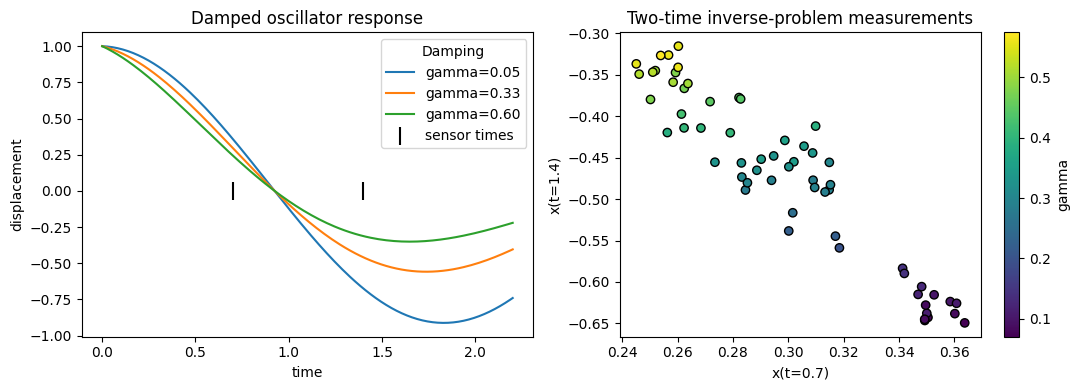

In [3]:
time_grid = np.linspace(0.0, 2.2, 160)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for g in [gamma_min, 0.5 * (gamma_min + gamma_max), gamma_max]:
    axes[0].plot(time_grid, np.exp(-g * time_grid) * np.cos(omega * time_grid), label=f"gamma={g:.2f}")
axes[0].scatter([t1, t2], [0, 0], marker="|", s=180, color="black", label="sensor times")
axes[0].set_title("Damped oscillator response")
axes[0].set_xlabel("time")
axes[0].set_ylabel("displacement")
axes[0].legend(title="Damping")
scatter = axes[1].scatter(x_raw[:, 0], x_raw[:, 1], c=gamma, cmap="viridis", edgecolor="black")
axes[1].set_title("Two-time inverse-problem measurements")
axes[1].set_xlabel(f"x(t={t1})")
axes[1].set_ylabel(f"x(t={t2})")
fig.colorbar(scatter, ax=axes[1], label="gamma")
plt.tight_layout()
plt.show()


## Package-client quantum inverse model

In [4]:
def train_small_vqr(x_train, y_train, *, seed, n_layers=2, steps=70, step_size=0.08):
    n_qubits = x_train.shape[1]
    wires = list(range(n_qubits))
    dev = pl.device("default.qubit", wires=n_qubits, seed=seed)

    @pl.qnode(dev, interface="autograd")
    def circuit(sample, params):
        apply_angle_embedding(sample, wires=wires)
        apply_hardware_efficient_ansatz(params, wires=wires)
        return pl.expval(pl.PauliZ(wires[0]))

    def predict_batch(samples, params):
        return pnp.array([circuit(sample, params) for sample in samples])

    def cost(params):
        preds = predict_batch(x_train, params)
        return pnp.mean((preds - pnp.asarray(y_train, dtype=float)) ** 2)

    rng = np.random.default_rng(seed)
    init = 0.01 * rng.standard_normal(parameter_shape(n_layers=n_layers, n_qubits=n_qubits))
    params = pnp.array(init, requires_grad=True)
    opt = get_optimizer("adam", stepsize=step_size)

    def step_fn(current_params):
        return opt.step_and_cost(cost, current_params)

    params, loss_history = run_training_loop(step_fn, params, steps)

    def predict(samples):
        return np.asarray(predict_batch(samples, params), dtype=float)

    return params, loss_history, predict

In [5]:
params, loss_history, predict = train_small_vqr(
    x_train, y_train, seed=19, n_layers=2, steps=85, step_size=0.07
)


def unscale_gamma(y_value):
    return gamma_min + 0.5 * (np.asarray(y_value) + 1.0) * (gamma_max - gamma_min)


q_scaled_pred = np.clip(predict(x_test), -1.0, 1.0)
q_gamma_pred = unscale_gamma(q_scaled_pred)

ridge = Ridge(alpha=1e-3)
ridge.fit(x_train, y_train)
ridge_gamma_pred = unscale_gamma(np.clip(ridge.predict(x_test), -1.0, 1.0))

results = {
    "quantum_gamma_mae": mean_absolute_error(gamma_test, q_gamma_pred),
    "ridge_gamma_mae": mean_absolute_error(gamma_test, ridge_gamma_pred),
    "initial_loss": float(loss_history[0]),
    "final_loss": float(loss_history[-1]),
    "loss_steps": len(loss_history),
}
print_section(
    "Results",
    [
        ("Quantum gamma MAE", results["quantum_gamma_mae"]),
        ("Ridge gamma MAE", results["ridge_gamma_mae"]),
        ("Initial loss", results["initial_loss"]),
        ("Final loss", results["final_loss"]),
        ("Loss steps", results["loss_steps"]),
    ],
)

Results
+-------------------+-----------+
| Metric            | Value     |
+-------------------+-----------+
| Quantum gamma MAE | 0.0562714 |
| Ridge gamma MAE   | 0.0177185 |
| Initial loss      | 0.829008  |
| Final loss        | 0.0328188 |
| Loss steps        | 85        |
+-------------------+-----------+



## Plots

The plots show the inverse-problem measurement space, quantum-regressor training loss, and recovered damping coefficients on the held-out set.

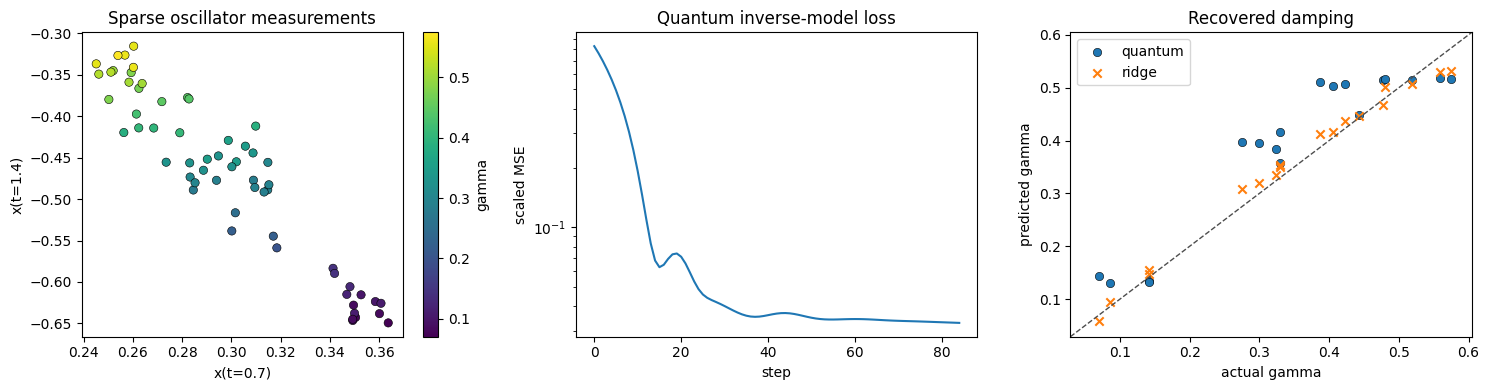

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scatter = axes[0].scatter(
    x_raw[:, 0], x_raw[:, 1], c=gamma, cmap="viridis", edgecolor="black", linewidth=0.4
)
axes[0].set_title("Sparse oscillator measurements")
axes[0].set_xlabel(f"x(t={t1})")
axes[0].set_ylabel(f"x(t={t2})")
fig.colorbar(scatter, ax=axes[0], label="gamma")

axes[1].plot(loss_history, color="tab:blue")
axes[1].set_title("Quantum inverse-model loss")
axes[1].set_xlabel("step")
axes[1].set_ylabel("scaled MSE")
axes[1].set_yscale("log")

limit_low = min(gamma_test.min(), q_gamma_pred.min(), ridge_gamma_pred.min()) - 0.03
limit_high = max(gamma_test.max(), q_gamma_pred.max(), ridge_gamma_pred.max()) + 0.03
axes[2].scatter(gamma_test, q_gamma_pred, label="quantum", edgecolor="black", linewidth=0.4)
axes[2].scatter(gamma_test, ridge_gamma_pred, label="ridge", marker="x")
axes[2].plot(
    [limit_low, limit_high], [limit_low, limit_high], color="0.3", linestyle="--", linewidth=1
)
axes[2].set_xlim(limit_low, limit_high)
axes[2].set_ylim(limit_low, limit_high)
axes[2].set_title("Recovered damping")
axes[2].set_xlabel("actual gamma")
axes[2].set_ylabel("predicted gamma")
axes[2].legend()

fig.tight_layout()
plt.show()

## Validation block

This final cell prints the recovered damping coefficients and checks that the inverse model trained and recovered `gamma` within a useful tolerance.

In [7]:
validation = {
    "dataset": {
        "problem": "damped_oscillator_damping_inference",
        "features": [f"x(t={t1})", f"x(t={t2})"],
        "target": "damping_gamma",
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
    },
    "results": results,
    "sample_recoveries": [
        {"actual_gamma": float(a), "quantum_gamma": float(q), "ridge_gamma": float(r)}
        for a, q, r in zip(gamma_test[:6], q_gamma_pred[:6], ridge_gamma_pred[:6])
    ],
    "passed": bool(
        np.isfinite(q_gamma_pred).all()
        and results["final_loss"] < results["initial_loss"]
        and results["quantum_gamma_mae"] < 0.18
    ),
}

print("Validation")
print_section(
    "Dataset",
    [
        ("Problem", validation["dataset"]["problem"]),
        ("Features", validation["dataset"]["features"]),
        ("Target", validation["dataset"]["target"]),
        ("Train samples", validation["dataset"]["n_train"]),
        ("Test samples", validation["dataset"]["n_test"]),
    ],
)
print_section(
    "Results",
    [
        ("Quantum gamma MAE", validation["results"]["quantum_gamma_mae"]),
        ("Ridge gamma MAE", validation["results"]["ridge_gamma_mae"]),
        ("Initial loss", validation["results"]["initial_loss"]),
        ("Final loss", validation["results"]["final_loss"]),
        ("Loss steps", validation["results"]["loss_steps"]),
    ],
)
print("Sample recoveries")
for index, row in enumerate(validation["sample_recoveries"], start=1):
    print(
        f"{index}. Actual gamma: {row['actual_gamma']:.6f}, "
        f"Quantum gamma: {row['quantum_gamma']:.6f}, "
        f"Ridge gamma: {row['ridge_gamma']:.6f}"
    )
print()
print("Interpretation")
print(
    "The quantum inverse model trained successfully and recovers damping coefficients within the validation tolerance."
)
print(
    "The ridge baseline is stronger on this simple inverse problem, so this validates package usage rather than quantum advantage."
)
print()
print(f"Passed: {validation['passed']}")
assert validation["passed"]

Validation
Dataset
+---------------+-------------------------------------+
| Metric        | Value                               |
+---------------+-------------------------------------+
| Problem       | damped_oscillator_damping_inference |
| Features      | [x(t=0.7), x(t=1.4)]                |
| Target        | damping_gamma                       |
| Train samples | 42                                  |
| Test samples  | 18                                  |
+---------------+-------------------------------------+

Results
+-------------------+-----------+
| Metric            | Value     |
+-------------------+-----------+
| Quantum gamma MAE | 0.0562714 |
| Ridge gamma MAE   | 0.0177185 |
| Initial loss      | 0.829008  |
| Final loss        | 0.0328188 |
| Loss steps        | 85        |
+-------------------+-----------+

Sample recoveries
1. Actual gamma: 0.405297, Quantum gamma: 0.502452, Ridge gamma: 0.415919
2. Actual gamma: 0.299665, Quantum gamma: 0.396080, Ridge gamma: 0.31